TASK - 3 :  Deep-Dive Analysis & Interactive Dashboarding

Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Loading

The dataset is loaded into a Pandas DataFrame for analysis.  
Initial inspection of the dataset helps understand its structure, including the number of rows and columns.

In [ ]:
# Load dataset
df = pd.read_csv("/content/online_retail.csv")
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


1. Define Core KPIs :

In [ ]:
# ---------------------------
# Create Total Price column (if not already created)
# ---------------------------
df['total price'] = df['Quantity'] * df['UnitPrice']

# ---------------------------
# KPI 1: Total Revenue
# ---------------------------
total_revenue = df['total price'].sum()

# ---------------------------
# KPI 2: Total Orders
# ---------------------------
total_orders = df['InvoiceNo'].nunique()

# ---------------------------
# KPI 3: Total Customers
# ---------------------------
total_customers = df['CustomerID'].nunique()

# ---------------------------
# KPI 4: Average Order Value (AOV)
# ---------------------------
avg_order_value = total_revenue / total_orders

# ---------------------------
# KPI 5: Revenue per Customer
# ---------------------------
revenue_per_customer = total_revenue / total_customers

# ---------------------------
# Print KPIs
# ---------------------------
print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", avg_order_value)
print("Revenue per Customer:", revenue_per_customer)

Total Revenue: 9747747.933999998
Total Orders: 25900
Total Customers: 4372
Average Order Value: 376.36092409266405
Revenue per Customer: 2229.5855292772185


2. Deep-Dive Analysis :

In [ ]:
import pandas as pd

# Ensure datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d-%m-%Y %H:%M')

# Create Total Price column
df['total price'] = df['Quantity'] * df['UnitPrice']

# Reference date (latest date in dataset)
reference_date = df['InvoiceDate'].max()

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'total price': 'sum'                                       # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# ---------------------------
# RFM Scoring (1–4 scale)
# ---------------------------

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Combine scores
rfm['RFM Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm.head())

            Recency  Frequency  Monetary R_score F_score M_score RFM Score
CustomerID                                                                
12346.0         325          2      0.00       1       2       1       121
12347.0           1          7   4310.00       4       4       4       444
12348.0          74          4   1797.24       2       3       4       234
12349.0          18          1   1757.55       3       1       4       314
12350.0         309          1    334.40       1       1       2       112


In [ ]:
#Customer Segmentation Logic
def segment_customer(row):
    if row['RFM Score'] == '444':
        return 'Best Customers'
    elif row['R_score'] == 4:
        return 'Recent Customers'
    elif row['F_score'] == 4:
        return 'Frequent Customers'
    elif row['M_score'] == 4:
        return 'High Spenders'
    else:
        return 'Low Value Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
Low Value Customers    2544
Recent Customers        633
Best Customers          498
Frequent Customers      487
High Spenders           210
Name: count, dtype: int64


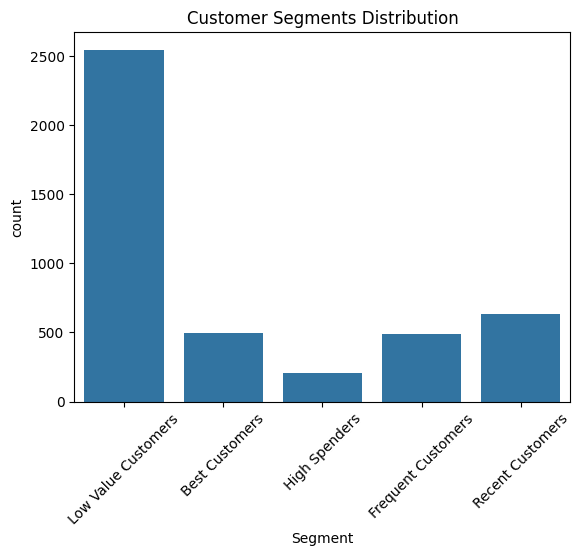

In [ ]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', data=rfm)
plt.title("Customer Segments Distribution")
plt.xticks(rotation=45)
plt.show()

Explanation

Customer segmentation using RFM analysis helps categorize customers based on their purchasing behavior. This allows businesses to design targeted marketing strategies, improve retention, and maximize revenue.